In [19]:
import pandas as pd
from pathlib import Path
from sklearn import metrics
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

In [20]:
data_dir = Path("data")
INDIR = Path("data/data_processed")
OUTDIR = Path("data/data_model")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [21]:
arquivo = INDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_SP_MODELO.csv"
X_scaled = pd.read_csv(arquivo, encoding='utf-8')

In [22]:
X_scaled.head()

,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_LOG_MEDIANA,REGIAO_CAPITAL,REGIAO_INTERIOR,REGIAO_LITORAL
0,1.022390,1.396181,1.042146,1.283894,0.920630,0.029932,0,1,0
1,0.645105,0.251115,0.302612,0.606230,0.723615,1.275477,0,1,0
2,1.564521,1.649462,1.412722,1.570834,1.234435,2.354417,0,1,0
3,1.394066,1.183277,1.205768,1.491113,0.617502,1.275477,0,1,0
4,-0.547368,-0.977093,-0.835371,-0.230580,-0.123298,0.029932,0,1,0


In [23]:
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

df_inertia = pd.DataFrame({
    'k': k_range,
    'inertia': inertia_values
}).set_index('k')

knee = KneeLocator(
    x=df_inertia.index,
    y=df_inertia['inertia'],
    curve='convex',
    direction='decreasing'
)

k_elbow = knee.knee

if k_elbow is None:
    print('Elbow não encontrado')
else:
    print(f'Elbow encontrado em k={k_elbow}')

Elbow encontrado em k=4


In [24]:
df_inertia.round(2)

,inertia
k,
2,606.62
3,411.59
4,335.35
5,300.58
6,267.06
7,237.39
8,212.14
9,191.42
10,176.99


In [25]:
k_range = range(2, 11)

ch_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.calinski_harabasz_score(X_scaled, labels)
    ch_values.append(score)

df_ch = pd.DataFrame({
    'k': k_range,
    'calinski_harabasz': ch_values
}).set_index('k')

k_ch = df_ch['calinski_harabasz'].idxmax()
print(f"Melhor valor de k (Calinski-Harabasz): {k_ch}")

Melhor valor de k (Calinski-Harabasz): 2


In [26]:
df_ch.round(2)

,calinski_harabasz
k,
2,233.63
3,220.38
4,195.06
5,168.36
6,155.97
7,149.74
8,146.35
9,143.93
10,139.49


In [27]:
k_range = range(2, 11)
db_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.davies_bouldin_score(X_scaled, labels)
    db_values.append(score)

df_db = pd.DataFrame({
    'k': k_range,
    'davies_bouldin': db_values
}).set_index('k')

k_db = df_db['davies_bouldin'].idxmin()
print(f"Melhor valor de k (Davies-Bouldin): {k_db}")

Melhor valor de k (Davies-Bouldin): 2


In [28]:
df_db.round(2)

,davies_bouldin
k,
2,0.87
3,0.94
4,1.05
5,1.19
6,1.09
7,1.11
8,1.06
9,1.04
10,1.03


In [29]:
k_range = range(2, 11)
silhouette_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)

    score = metrics.silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=0
    )
    
    silhouette_values.append(score)

df_silhouette = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_values
}).set_index('k')

k_sil = df_silhouette['silhouette'].idxmax()
k_sil

2

In [30]:
df_silhouette

,silhouette
k,
2,0.419333
3,0.355095
4,0.300396
5,0.285912
6,0.289992
7,0.289583
8,0.296757
9,0.301864
10,0.308501


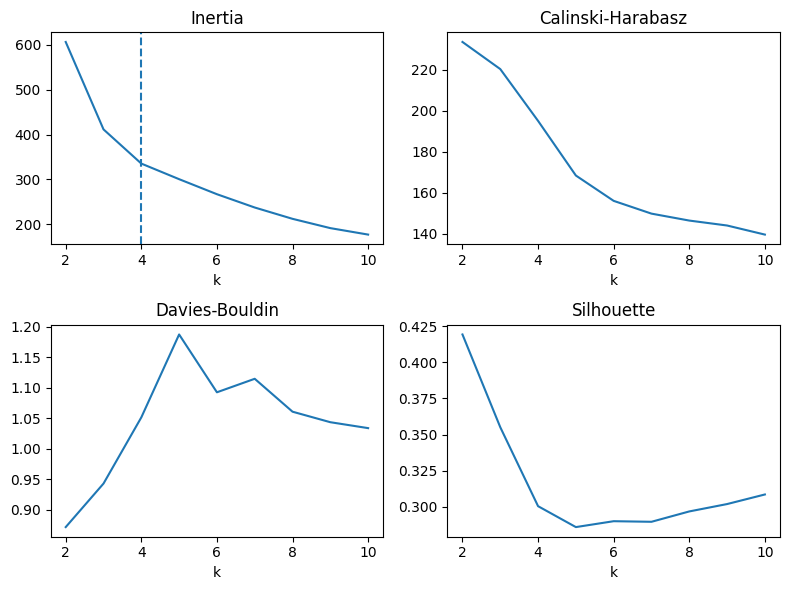

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))


df_inertia['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_elbow is not None:
    axes[0, 0].axvline(k_elbow, linestyle='--')


df_ch['calinski_harabasz'].plot(ax=axes[0, 1], title='Calinski-Harabasz')

df_db['davies_bouldin'].plot(ax=axes[1, 0], title='Davies-Bouldin')

df_silhouette['silhouette'].plot(ax=axes[1, 1], title='Silhouette')

plt.tight_layout()